In [3]:
!pip install yfinance arch pmdarima

In [4]:

from __future__ import annotations

import os
from itertools import combinations
from typing import Tuple

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from arch.univariate.base import ARCHModelResult
from arch.univariate.mean import ZeroMean
from arch.univariate.volatility import GARCH
from numpy.linalg import det, inv
from pmdarima.arima import ARIMA
from scipy.optimize import minimize


In [5]:
# --- CLASS 1: UGARCH (Univariate GARCH) ---
class UGARCH:
    """Univariate GARCH volatility modelling (GJR-GARCH specification)."""

    def __init__(self, order: tuple[int, int] = (1, 1)) -> None:
        self.order = order
        self.order_p, self.order_q = self.order
        self._returns: np.ndarray = None
        self.asset: str = None
        self.mean_model: ARIMA = None
        self.vol_model: GARCH = None
        self.fitted_mean_model: ARIMA = None
        self.fitted_vol_model: ARCHModelResult = None
        self.cond_vol: np.ndarray = None
        self.std_resid: np.ndarray = None
        self.resid: np.ndarray = None
        self.fc_means: np.ndarray = None
        self.fc_vol: np.ndarray = None
        self.n_ahead: int = None

    @property
    def returns(self) -> np.ndarray:
        return self._returns

    @returns.setter
    def returns(self, returns: pd.Series) -> None:
        self._returns = returns.to_numpy()
        self.asset = returns.name
        self.dates = returns.index

    def spec(self, returns: pd.Series) -> None:
        self.returns = returns
        # ARMA(1,1) per la media
        self.mean_model = ARIMA(order=(self.order_p, 0, self.order_q))
        # GJR-GARCH(1,1) per la volatilità (o=1 attiva l'asimmetria)
        self.vol_model = GARCH(p=self.order_p, o=self.order_p, q=self.order_q)

    def fit(self) -> None:
        # 1. Fit Media
        self.fitted_mean_model = self.mean_model.fit(self.returns)
        arma_resids = self.fitted_mean_model.resid()

        # 2. Fit Volatilità sui residui
        self.fitted_vol_model = ZeroMean(
            y=arma_resids,
            volatility=self.vol_model,
        ).fit(disp="off")

        self.std_resid = self.fitted_vol_model.std_resid
        self.cond_vol = self.fitted_vol_model.conditional_volatility
        self.resid = self.fitted_vol_model.resid

    def forecast(self, n_ahead: int) -> None:
        self.n_ahead = n_ahead
        self.fc_means = self.fitted_mean_model.predict(n_periods=self.n_ahead)
        fc_vol_model = self.fitted_vol_model.forecast(horizon=self.n_ahead, reindex=True)
        # Prende l'ultimo valore di varianza prevista e ne fa la radice quadrata
        self.fc_vol = np.sqrt(fc_vol_model.variance.tail(1).T.to_numpy().ravel())

In [6]:
# --- CLASS 2: DCCGARCH (Multivariate GARCH) ---
class DCCGARCH:
    """Dynamic Conditional Correlation (DCC) GARCH modelling."""

    def __init__(self) -> None:
        self.assets: list[str] = []
        self.dates: pd.Index = None
        self.ugarch_objs: list[UGARCH] = []
        self.std_resids: np.ndarray = None
        self.cond_vols: np.ndarray = None
        self.cond_cor: np.ndarray = None
        self.dcc_a: float = None
        self.dcc_b: float = None
        self.fc_means: np.ndarray = None
        self.fc_vols: np.ndarray = None
        self.fc_cor: np.ndarray = None
        self.fc_cov: np.ndarray = None
        self.n_ahead: int = None

    def spec(self, ugarch_objs: list[UGARCH], returns: pd.DataFrame) -> None:
        self.assets = returns.columns.to_list()
        self.dates = returns.index
        self.ugarch_objs = ugarch_objs

        # Passa i dati ai singoli modelli GARCH
        for i, garch_obj in enumerate(self.ugarch_objs):
            garch_obj.spec(returns.iloc[:, i])

    def fit(self) -> None:
        print(">> Fitting 3 Univariate GJR-GARCH Models...")
        for garch_obj in self.ugarch_objs:
            garch_obj.fit()

        # Raccoglie residui standardizzati e volatilità condizionali
        self.std_resids = np.array([g.std_resid for g in self.ugarch_objs]).T
        self.cond_vols = np.array([g.cond_vol for g in self.ugarch_objs]).T
        self.n_assets = len(self.assets)

        print(">> Estimating DCC Parameters (a, b)...")
        self.estimate_params()

        # Calcola le correlazioni storiche dinamiche
        self.cond_cor, _ = self.dynamic_corr(
            res=self.std_resids,
            cvol=self.cond_vols,
            dcc_a=self.dcc_a,
            dcc_b=self.dcc_b,
        )

    def forecast(self, n_ahead: int) -> None:
        self.n_ahead = n_ahead

        # 1. Previsioni Univariate (Media e Volatilità)
        for garch_obj in self.ugarch_objs:
            garch_obj.forecast(self.n_ahead)

        self.fc_means = np.array([g.fc_means for g in self.ugarch_objs]).T
        self.fc_vols = np.array([g.fc_vol for g in self.ugarch_objs]).T

        # 2. Previsione Correlazione DCC
        R0 = self.cond_cor[:, :, -1]  # Ultima correlazione osservata
        Q_bar = np.cov(self.std_resids, rowvar=False) # Correlazione incondizionata (Target)

        self.fc_cor = np.zeros((self.n_assets, self.n_assets, self.n_ahead))

        decay = self.dcc_a + self.dcc_b

        for k in range(1, self.n_ahead + 1):
            # Previsione Mean-Reverting: R_{t+k} = (1 - (a+b)^k) * R_bar + (a+b)^k * R_t
            weight_long_run = (1 - decay**k)
            weight_short_run = (decay**k)

            self.fc_cor[:, :, k - 1] = weight_long_run * Q_bar + weight_short_run * R0

        # 3. Previsione Covarianza
        self.fc_cov = np.zeros((self.n_assets, self.n_assets, self.n_ahead))
        for k in range(self.n_ahead):
            D = np.diag(self.fc_vols[k, :])
            self.fc_cov[:, :, k] = np.dot(D.T, np.dot(self.fc_cor[:, :, k], D))

    @staticmethod
    def dynamic_corr(res: np.ndarray, cvol: np.ndarray, dcc_a: float, dcc_b: float) -> Tuple[np.ndarray, np.ndarray]:
        n_periods, n_assets = res.shape
        Q_bar = np.cov(res, rowvar=False)

        Q = np.zeros((n_assets, n_assets, n_periods))
        Q[:, :, 0] = Q_bar

        # Outer product dei residui
        Z = np.zeros((n_assets, n_assets, n_periods))
        for i in range(n_periods):
            Z[:, :, i] = np.outer(res[i, :], res[i, :].T)

        # DCC Recursion
        for i in range(1, n_periods):
            Q[:, :, i] = ((1 - dcc_a - dcc_b) * Q_bar + dcc_a * Z[:, :, i - 1] + dcc_b * Q[:, :, i - 1])

        # Correlation Matrix R
        R = np.zeros((n_assets, n_assets, n_periods))
        for i in range(n_periods):
            q_diag = np.diag(Q[:, :, i])
            inv_sqrt_diag = np.diag(1 / np.sqrt(q_diag))
            R[:, :, i] = np.dot(inv_sqrt_diag, np.dot(Q[:, :, i], inv_sqrt_diag))

        # Covariance Matrix H (opzionale per il plot, utile per debug)
        H = np.zeros((n_assets, n_assets, n_periods))
        # (Calcolo omesso per velocità se non richiesto esplicitamente, ma struttura lasciata)

        return R, H

    @classmethod
    def qllf(cls, params: list[float], args: list) -> float:
        res, cvol = args
        dcc_a, dcc_b = params

        # Vincoli di stazionarietà
        if dcc_a < 0 or dcc_b < 0 or (dcc_a + dcc_b) >= 0.9999:
             return 1e10

        R, _ = cls.dynamic_corr(res=res, cvol=cvol, dcc_a=dcc_a, dcc_b=dcc_b)

        ll = 0
        n_periods = res.shape[0]
        eye = np.eye(R.shape[1])

        for i in range(n_periods):
             try:
                # Piccola regolarizzazione per stabilità inversa
                R_reg = R[:, :, i] + eye * 1e-6

                # Log-Likelihood (parte di correlazione)
                ll += np.log(det(R_reg)) + np.dot(res[i, :].T, np.dot(inv(R_reg), res[i, :]))
             except np.linalg.LinAlgError:
                 return 1e10
        return 0.5 * ll

    def estimate_params(self) -> None:
        # Vincoli: a+b < 1, a>0, b>0
        constr = [
            {"type": "ineq", "fun": lambda x: 0.9999 - np.sum(x)},
            {"type": "ineq", "fun": lambda x: x[0]},
            {"type": "ineq", "fun": lambda x: x[1]},
        ]
        x0 = [0.05, 0.90] # Starting guess

        solution = minimize(
            fun=self.qllf, x0=x0, args=[self.std_resids, self.cond_vols],
            constraints=constr, method='SLSQP', options={"disp": False},
        )
        self.dcc_a, self.dcc_b = solution.x

    # --- PLOTTING METHODS ---
    def plot_volatility(self) -> None:
        plt.style.use('seaborn-v0_8-whitegrid')
        for i, asset in enumerate(self.assets):
            plt.figure(figsize=(10, 5))
            # Plot Volatilità (già in scala % se returns sono *100)
            plt.plot(self.dates, self.cond_vols[:, i], color='darkblue', lw=1)

            plt.title(f"Volatilità Condizionale (GARCH): {asset}", fontsize=13, weight='bold')
            plt.ylabel("Volatilità (%)", fontsize=11)
            plt.xlabel("Data", fontsize=11)

            plt.grid(True, linestyle=':', alpha=0.6)
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    def plot_correlation(self) -> None:
        plt.style.use('seaborn-v0_8-whitegrid')
        pairs = list(combinations(range(len(self.assets)), 2))

        for i, j in pairs:
            asset1 = self.assets[i]
            asset2 = self.assets[j]

            plt.figure(figsize=(10, 5))
            plt.plot(self.dates, self.cond_cor[i, j, :], color='darkred', lw=1)

            plt.title(f"Correlazione Dinamica (DCC): {asset1} vs {asset2}", fontsize=13, weight='bold')
            plt.ylabel("Correlazione", fontsize=11)
            plt.ylim(-1.0, 1.0)

            # Linea dello zero
            plt.axhline(0, color='black', lw=1, linestyle='--')

            plt.grid(True, linestyle=':', alpha=0.6)
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()




--- 1. LETTURA DATI: Zeri_Tommaso.xlsx ---
Calcolo Log-Returns (moltiplicati x100)...
Dati pronti: 2264 osservazioni.

--- 2. FITTING MODELLO ---
>> Fitting 3 Univariate GJR-GARCH Models...
>> Estimating DCC Parameters (a, b)...

[RISULTATO] Parametri DCC stimati:
Alpha (a): 0.00718
Beta  (b): 0.98700
Somma (Decay): 0.99418

--- 3. STATISTICHE ---
>>> Matrice di Correlazione Media (sul periodo):
        Price1  Price2  Price3
Price1  1.0000  0.3102  0.3626
Price2  0.3102  1.0000  0.2586
Price3  0.3626  0.2586  1.0000

--- 4. GENERAZIONE GRAFICI ---
Generazione plot Volatilità...


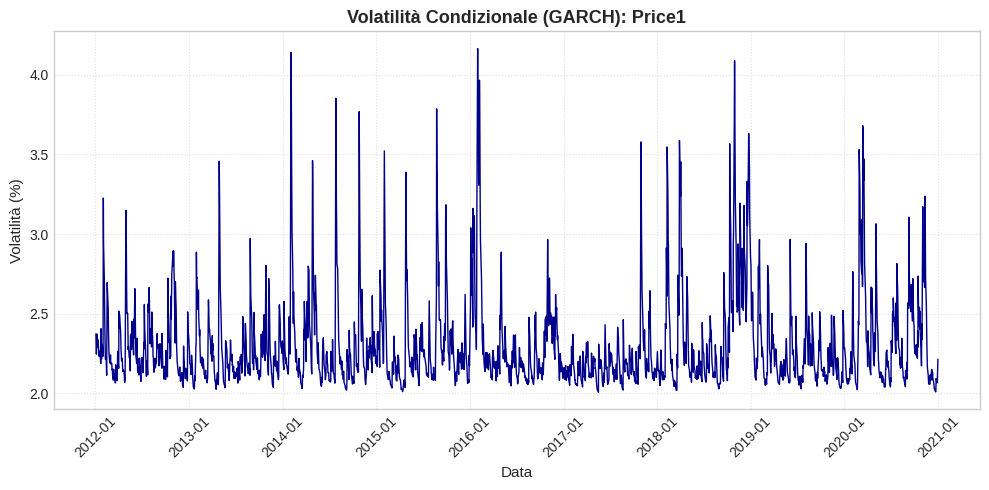

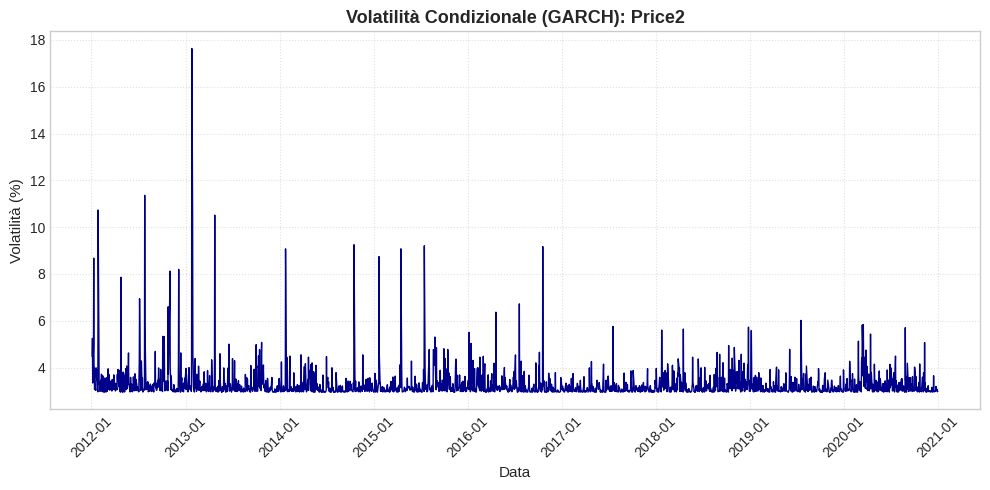

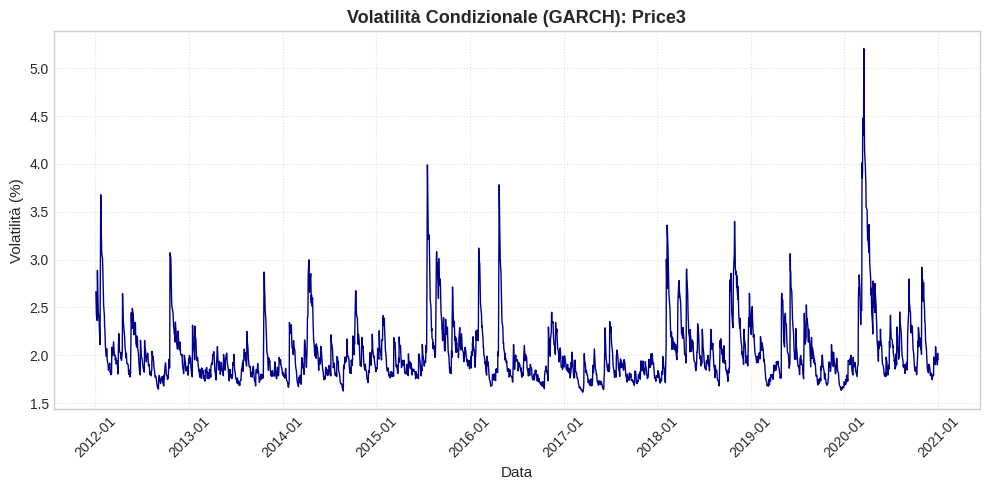

Generazione plot Correlazioni...


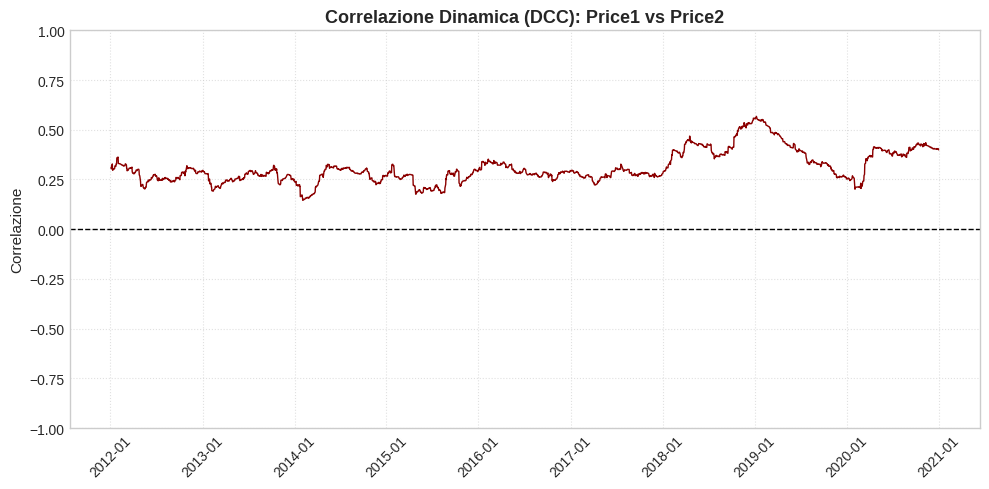

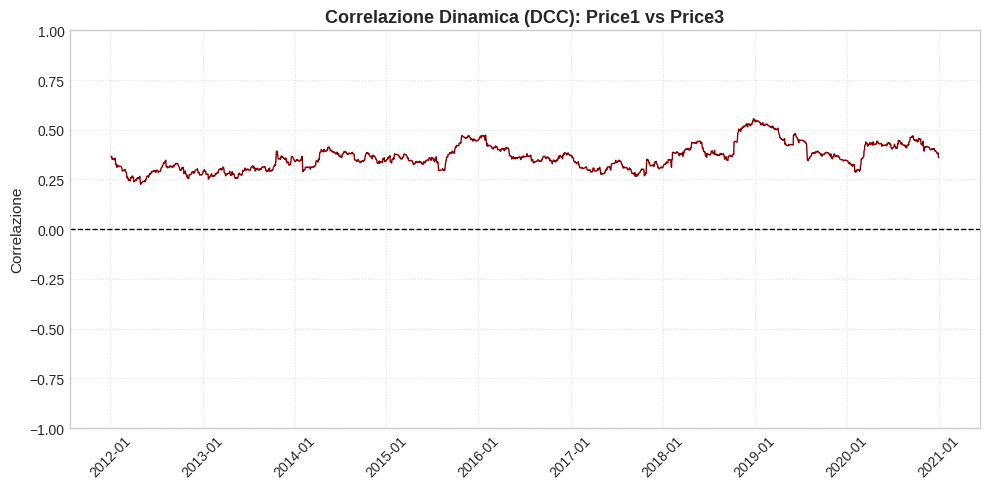

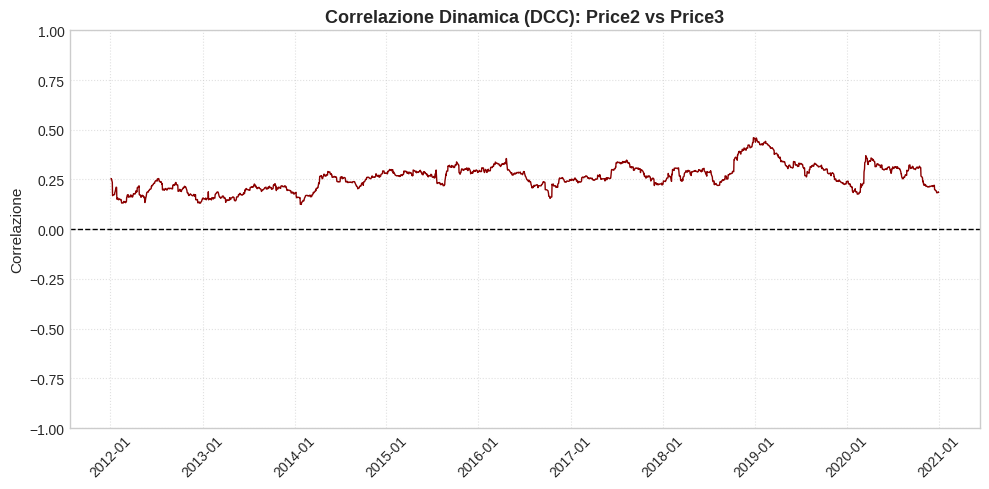


[COMPLETATO] Script terminato con successo.


In [7]:
# --- MAIN EXECUTION BLOCK ---
if __name__ == "__main__":
    file_name = "Zeri_Tommaso.xlsx"
    sheet_name = "Ex.2"

    print(f"--- 1. LETTURA DATI: {file_name} ---")

    # Check file
    if not os.path.exists(file_name):
        print(f"ERRORE CRITICO: Il file '{file_name}' non è stato trovato nella cartella.")
        print("Assicurati di aver caricato il file Excel.")
        exit()

    # 1. Caricamento Excel
    try:
        raw_df = pd.read_excel(
            file_name,
            sheet_name=sheet_name,
            decimal=',',         # Fondamentale per leggere "176,33" come numero
            parse_dates=['Date']
        )
    except ValueError as e:
        print(f"Errore lettura Excel: {e}")
        exit()

    # Fix Data
    raw_df['Date'] = pd.to_datetime(raw_df['Date'], dayfirst=True)
    raw_df.set_index('Date', inplace=True)

    # Selezione colonne prezzi
    target_cols = ["Price1", "Price2", "Price3"]
    data = raw_df[target_cols].dropna()

    # 2. Calcolo Log-Returns Moltiplicati per 100
    # MOLTO IMPORTANTE: * 100 scala i dati (es. 0.01 diventa 1.0)
    # Questo evita i "DataScaleWarning" e aiuta l'ottimizzatore a convergere.
    print("Calcolo Log-Returns (moltiplicati x100)...")
    returns = 100 * np.log(data / data.shift(1)).dropna()

    print(f"Dati pronti: {returns.shape[0]} osservazioni.")

    # 3. Inizializzazione e Fit
    print("\n--- 2. FITTING MODELLO ---")

    # Creazione lista modelli univariati
    ugarch_list = [UGARCH(order=(1, 1)) for _ in range(len(target_cols))]

    # DCC Model
    dcc = DCCGARCH()
    dcc.spec(ugarch_list, returns)
    dcc.fit()

    print(f"\n[RISULTATO] Parametri DCC stimati:")
    print(f"Alpha (a): {dcc.dcc_a:.5f}")
    print(f"Beta  (b): {dcc.dcc_b:.5f}")
    print(f"Somma (Decay): {dcc.dcc_a + dcc.dcc_b:.5f}")

    # 4. Statistiche
    print("\n--- 3. STATISTICHE ---")
    dcc.forecast(n_ahead=1)

    # Matrice media storica delle correlazioni dinamiche
    avg_corr = np.mean(dcc.cond_cor, axis=2)
    df_corr = pd.DataFrame(avg_corr, index=target_cols, columns=target_cols)

    print(">>> Matrice di Correlazione Media (sul periodo):")
    pd.options.display.float_format = '{:.4f}'.format
    print(df_corr)

    # 5. Grafici
    print("\n--- 4. GENERAZIONE GRAFICI ---")
    print("Generazione plot Volatilità...")
    dcc.plot_volatility()

    print("Generazione plot Correlazioni...")
    dcc.plot_correlation()

    print("\n[COMPLETATO] Script terminato con successo.")